# Working with FITS Files in Astronomy
This notebook explores how to open and visualize FITS (Flexible Image Transport System) files
using the `astropy` library. We'll also detect stars in the image and measure their brightness using aperture photometry.

The data used here is from the **Hubble Space Telescope (HST)**, observing the globular cluster **NGC 1261**.

In [2]:
from astropy.io import fits
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [3]:
# fits_file = fits.open('sample_data/hlsp_hugs_hst_wfc3-uvis_ngc1261_f275w_v1_stack-0859s.fits',memmap=True)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
from astropy.io import fits
fits_file = fits.open('/content/drive/MyDrive/Astropy_data/hlsp_hugs_hst_acs-wfc_ngc1261_f814w_v1_stack-0360s.fits',memmap=True)

In [9]:
fits_file.info()

Filename: /content/drive/MyDrive/Astropy_data/hlsp_hugs_hst_acs-wfc_ngc1261_f814w_v1_stack-0360s.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      37   (10000, 10000)   float32   


In [10]:
# extract data from the fits file
image_data = fits_file[0].data
print(image_data)

[[-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 ...
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]]


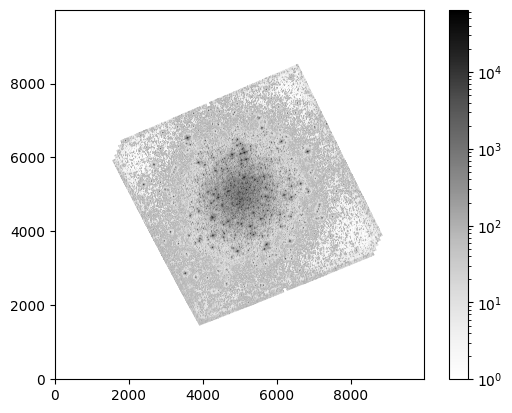

In [11]:
plt.figure()
plt.imshow(image_data, origin = 'lower', cmap='Greys', norm=LogNorm())
plt.colorbar()
plt.show()

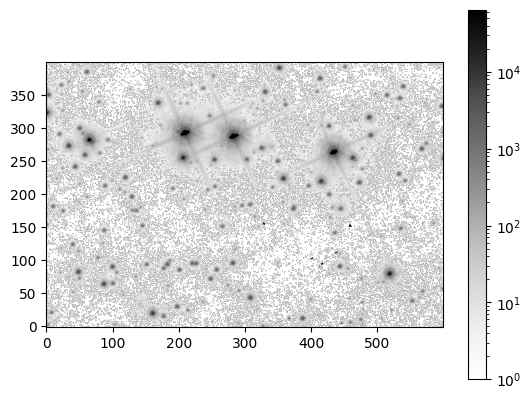

In [13]:
# zoom to specific region
section1 = image_data[2250:2650, 5350:5950]

plt.figure()
plt.imshow(section1, origin = 'lower', cmap='Greys', norm=LogNorm())
plt.colorbar()
plt.show()

To detect the stars, we first need to compute the background level of the image.
This is done using **sigma-clipped statistics**, which eliminates any outlier pixels (which include the stars)
and results in better estimates of the background values of mean, median, and std.

In [14]:
from astropy.stats import sigma_clipped_stats
mean, median, std = sigma_clipped_stats(section1,sigma=3.0) ## done to remove background noise as stars will have bright pixels
# print data
print((mean,median,std))

(np.float32(1.6487273), np.float32(0.0), np.float32(8.310026))


In [15]:
!pip install photutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.7 MB/s eta 0:00:00


In [16]:
from photutils.detection import DAOStarFinder

Full Width at Half Maximum (FWHM): It should be noted that when you observe stars using your telescope,
the images are not perfect dots due to optical reasons. The FWHM measurement simply
shows how large the image is specifically, the width measured in a position where
the star has half of its maximum brightness. A common FWHM value for stars is about
2 to 5 pixels.

In other words, this is what DAOStarFinder uses to tell if an object is a star or
not. If it is too large, it is more than likely a galaxy. If it is too sharp, it
must be the result of cosmic rays. Moreover, if it is just one pixel, it is usually
just noise and is not considered further.

In [17]:
daofind = DAOStarFinder(fwhm = 3.0, threshold = 5.0*std)

In [18]:
sources = daofind(section1 - median)

In [19]:
sources

id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,117.19840700978472,0.33785036168056076,0.8846123179726927,-0.2011944,-0.5117449059733475,25,199.0,825.0,-7.291135,-1.32073485181937
2,428.43610547709443,0.35907893481994335,0.7683534876250196,-0.28911385,-0.7582980144215116,25,168.0,906.0,-7.392821,-1.16533344595785
3,327.4738420518488,1.0581984430187759,0.5090875494838024,0.018097313,-0.4046461506653635,25,619.0,4693.0,-9.178627,-2.7855312728467316
4,2.781675621797195,3.199504717857718,0.4921522364666041,-0.005720018,-0.05845276920351851,25,660.0,5258.0,-9.302052,-2.8639314725905933
5,103.1845886578103,3.4357616794705583,0.6561799290211228,0.101713486,0.003876608020714004,25,407.0,2881.0,-8.648858,-2.1393508704475837
6,290.5109175749493,5.254984032876488,0.4636890796578217,0.19119883,-0.02212417182261969,25,302.0,2500.0,-8.49485,-2.0350260955707
7,446.31110699174485,5.237290114773217,0.7678786987735149,0.3914525,-0.15181525632326792,25,1772.0,6806.0,-9.58223,-3.8259789304408405
8,459.61980785421247,6.530542495305512,0.7027840179038379,0.44616908,-0.005118942018582887,25,960.0,7055.0,-9.621243,-3.0088521872061884
9,241.67749237112199,7.762386462385146,0.5334789329358254,0.2096463,0.04539980823779566,25,113.0,739.0,-7.1716113,-0.9736467450176588


In [20]:
import numpy as np
from photutils.aperture import CircularAperture

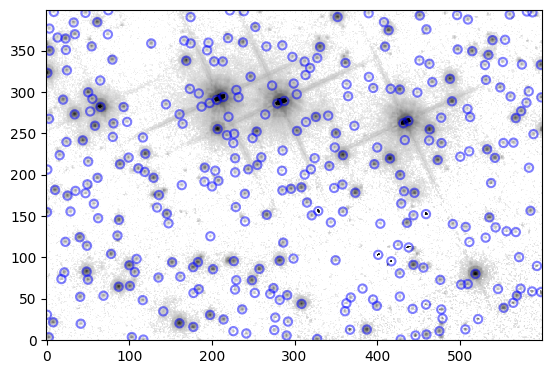

In [21]:
positions = np.transpose((sources['x_centroid'], sources['y_centroid']))
apertures = CircularAperture(positions, r= 5.0) #radius of appertures
plt.imshow(section1, cmap = 'Greys', origin = 'lower', norm = LogNorm(), interpolation = 'nearest')
apertures.plot(color = 'blue', lw = 1.5, alpha = 0.5);

###### Masking Very Bright Foreground Stars
There are some very bright stars in the picture that happen to be foreground stars and not in NGC 1261.
They’re so bright that they cause issues with our measurements, so we mask them out and re-do the star detection process.

In [22]:
bright_limit = median + 50*std ## to bright stars
mask = section1 > bright_limit

sources_bs = daofind(section1 - median, mask=mask)
print(f"Stars detected after masking: {len(sources_bs)}")

Stars detected after masking: 192


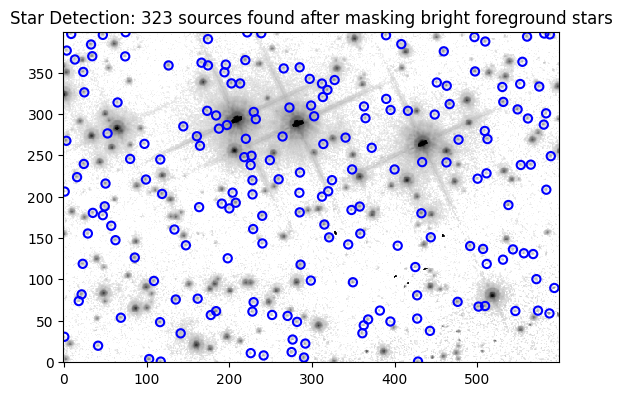

In [23]:
xpix = sources_bs['x_centroid']
ypix = sources_bs['y_centroid']

# plot new table
positions = np.transpose((xpix,ypix))
apertures = CircularAperture(positions,r=5.0)
plt.title(f'Star Detection: {len(sources)} sources found after masking bright foreground stars')
plt.imshow(section1, cmap='Greys', norm=LogNorm(), origin = 'lower', interpolation='nearest')
apertures.plot(color='blue',lw=1.5, alpha = 1);

## Aperture Photometry
To measure how bright each star is, we use **aperture photometry**:
1. Draw a circular aperture around each star and sum up the pixel values inside — this is the star's flux.
2. Draw a ring (annulus) around it to estimate the local background.
3. Subtract the background from the star flux to get the **net flux**.

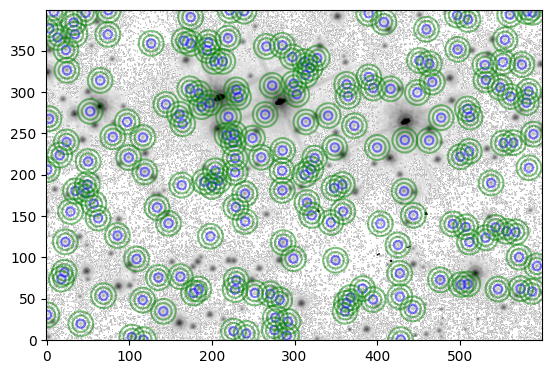

In [24]:
from photutils.aperture import CircularAnnulus, CircularAperture, ApertureStats, aperture_photometry

# define annuluses
annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

# plot annuluses
plt.figure()
plt.imshow(section1, cmap='Greys', norm = LogNorm(), origin = 'lower')
apertures.plot(color='blue',lw=1.5, alpha = 0.5);
annulus_aperture.plot(color='green',lw=1.5,alpha=0.5);
plt.show()

In [25]:
from astropy.stats import SigmaClip
sigma_clip = SigmaClip(sigma=3.0)
aperstats = ApertureStats(section1, annulus_aperture, sigma_clip=sigma_clip)
bkg_mean = aperstats.mean

aperture_area = apertures.area_overlap(section1)
total_bkg = bkg_mean *aperture_area

In [26]:
# perform aperture photometry
star_data = aperture_photometry(section1, apertures) #sum of the pixels of the stars

# add backgrounds to table
star_data['total_bkg'] = total_bkg

# format and print data
for col in star_data.colnames:
    star_data[col].info.format = '%.8g'
star_data.pprint()

 id  x_center  y_center  aperture_sum total_bkg 
--- --------- ---------- ------------ ----------
  1 117.19841 0.33785036    967.29562 -141.51916
  2 428.43611 0.35907893    1134.1804 -106.28906
  3 103.18459  3.4357617    3531.7091 -238.07877
  4 290.51092   5.254984    3165.6819 -47.752208
  5 241.67749  7.7623865    706.04205 -387.38856
  6  226.1103  10.548382    180.47829 -252.75541
  7 275.53169  11.858685    765.08713 -142.98867
  8 41.405737  19.512927    898.76403 -239.63683
  9 292.10226  22.108539    1088.7593 -81.495616
 10 276.74131  27.005602     758.7213 -144.51326
...       ...        ...          ...        ...
183 496.70783  392.87103    636.82146 -164.96648
184 560.32002  393.47255    1378.4357 -266.36566
185 47.174244  395.56539    968.20699  120.87792
186 389.72428  395.12727    827.51614 -106.88696
187 8.8729477  396.68106    637.12651 -79.693429
188 587.87268   396.1748    1374.7063 -227.62305
189 581.10246  397.19612     937.4546 -160.47592
190 221.84348  398.5

In [27]:
header = fits_file[0].header

# print entire header — shows everything
print(repr(header))

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                10000                                                  
NAXIS2  =                10000                                                  
EXTEND  =                    T                                                  
CRPIX1  =     0.5003061426E+04                                                  
CRPIX2  =     0.5000727417E+04                                                  
CRVAL1  =     0.4806754200E+02                                                  
CRVAL2  =    -0.5521622200E+02                                                  
CTYPE1  = 'RA---TAN'                                                            
CTYPE2  = 'DEC--TAN'                                                            
CD1_1   =   -0.109849110E-04

In [28]:
date       = header['DATE-OBS'].split('T')[0]  # removes time part
instrument = 'WFC'                              # acszpt format
filter     = header['FILTER']
extime     = header['EXPTIME']

print(f"Date:        {date}")
print(f"Instrument:  {instrument}")
print(f"Filter:      {filter}")
print(f"Exptime:     {extime}")

Date:        2006-03-10
Instrument:  WFC
Filter:      F814W
Exptime:     1800.0


In [29]:
!pip install acstools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.4/110.4 kB 1.4 MB/s eta 0:00:00


In [30]:
from acstools import acszpt

date = '2006-03-10'

instrument = 'WFC'

filter = 'F814W'

# fetch zeropoint from catalogue
q = acszpt.Query(date = date, detector = instrument)
zpt_table = q.fetch()
print(zpt_table)

Filter PHOTLAM             PHOTFLAM            STmag  VEGAmag  ABmag 
       Angstrom erg / (Angstrom electron cm2) mag(ST)   mag   mag(AB)
------ -------- ----------------------------- ------- ------- -------
 F435W   4329.3                    3.1201e-19  25.165   25.79  25.675
 F475W   4745.8                    1.8123e-19  25.754  26.172  26.065
 F502N   5023.0                    5.2075e-18  22.108  22.386  22.296
 F550M   5581.3                    3.9676e-19  24.904   24.84  24.862
 F555W   5360.2                    1.9522e-19  25.674   25.73   25.72
 F606W   5919.7                    7.7915e-20  26.671  26.415  26.501
 F625W   6311.2                    1.1869e-19  26.214  25.739  25.905
 F658N   6584.0                    1.9812e-18  23.158  22.387  22.757
 F660N   6599.4                    5.1794e-18  22.114  21.423  21.709
 F775W   7694.0                    9.9484e-20  26.406  25.269  25.667
 F814W   8047.9                    7.0156e-20  26.785  25.517  25.948
F850LP   9034.7     

In [31]:
q_filter = acszpt.Query(date = date, detector = instrument, filt = filter)
filter_zpt = q_filter.fetch()

# print data
print(filter_zpt)

Filter PHOTLAM             PHOTFLAM            STmag  VEGAmag  ABmag 
       Angstrom erg / (Angstrom electron cm2) mag(ST)   mag   mag(AB)
------ -------- ----------------------------- ------- ------- -------
 F814W   8047.9                    7.0156e-20  26.785  25.517  25.948


## MAGNITUDE = ZEROPOINT - 2.5*log_10{(APERTURE_SUM - TOTAL_BKG)/EXTIME}

In [32]:
import math

In [33]:
# use ABmag from filter_zpt
zeropoint = 25.948

extime = 1800.0

star_data['net_flux']  = star_data['aperture_sum'] - star_data['total_bkg']
star_data['magnitude'] = zeropoint - 2.5 * np.log10(np.abs(star_data['net_flux']) / extime)

star_data[:30].pprint(max_lines=-1, max_width=-1)

 id  x_center   y_center  aperture_sum total_bkg   net_flux magnitude
--- ---------- ---------- ------------ ---------- --------- ---------
  1  117.19841 0.33785036    967.29562 -141.51916 1108.8148 26.474034
  2  428.43611 0.35907893    1134.1804 -106.28906 1240.4695 26.352216
  3  103.18459  3.4357617    3531.7091 -238.07877 3769.7879 25.145389
  4  290.51092   5.254984    3165.6819 -47.752208 3213.4341 25.318758
  5  241.67749  7.7623865    706.04205 -387.38856 1093.4306 26.489203
  6   226.1103  10.548382    180.47829 -252.75541  433.2337 27.494376
  7  275.53169  11.858685    765.08713 -142.98867 908.07579 26.690876
  8  41.405737  19.512927    898.76403 -239.63683 1138.4009 26.445443
  9  292.10226  22.108539    1088.7593 -81.495616 1170.2549  26.41548
 10  276.74131  27.005602     758.7213 -144.51326 903.23456  26.69668
 11 0.55252858  30.344793    362.71638  30.961445 331.75493 27.784138
 12  141.32403   34.49867    2485.3297  464.88189 2020.4478 25.822562
 13  361.11493  34.6